Linear Algebra Fundamentals

1. Build Vector From Scratch

In [25]:
class Vector:
    def __init__(self, components:List):
        self.components = components
        self.dim = len(self.components)
    def __add__(self,other:Vector):
        return Vector([a+b for a,b in zip(self.components,other.components)])
        
    def __sub__(self,other):
        return Vector([a-b for a,b in zip(self.components,other.components)])

    def dot(self,other):
         return sum([a*b for a,b in zip(self.components,other.components)])

    def magnitude(self):
        return sum(i**2 for i in self.components)**0.5

    def normalize(self):
        magnitude = self.magnitude()
        return Vector([x/magnitude for x in self.components])

    def cosine_similarity(self,other):
        dot_product = self.dot(other)
        magnitude_self = self.magnitude()
        magnitude_other = other.magnitude()
        return dot_product/(magnitude_other*magnitude_self)

    def __repr__(self):
        return f"Vector({self.components})"

Testing

In [26]:
a = Vector([1,2,3])
b= Vector([2,3,4])
print(f"a + b = {a + b}")
print(f"a · b = {a.dot(b)}")
print(f"|a| = {a.magnitude():.4f}")
print(f"cosine similarity = {a.cosine_similarity(b):.4f}")

a + b = Vector([3, 5, 7])
a · b = 20
|a| = 3.7417
cosine similarity = 0.9926


2. Matrix from scratch

In [36]:
class Matrix:
    def __init__(self,rows):
        self.rows = [list(row) for row in rows]
        self.shape = [len(self.rows),len(self.rows[0])]
    def __matmul__(self,other):
        if isinstance(other,Vector):
            return Vector([
                sum(self.rows[i][j]* other.components[j] for j in range(self.shape[1]))
                    for i in range(self.shape[0])
            ])
        rows = []
        for i in range(self.shape[0]):
            row = []
            for j in range(other.shape[1]):
                    row.append(sum(
                        self.row[i][k]*other.rows[k][j]
                        for k in range(self.shape[1])
                    ))
            rows.append(row)
        return Matrix(rows)
    def transpose(self):
        return Matrix([
            [self.rows[j][i] for j in range(self.shape[0])]
            for i in range(self.shape[1])
        ])     
    def __repr__(self):
        return f"Matrix ({self.rows})"
        
rotation_90 = Matrix([[0, -1], [1, 0]])
point = Vector([3, 1])

rotated = rotation_90 @ point
print(f"Original: {point}")
print(f"Rotated 90°: {rotated}")

Original: Vector([3, 1])
Rotated 90°: Vector([-1, 3])


Step 3: Why this matters for AI

In [38]:
import random
random.seed(42)
weights = Matrix([[random.gauss(0,0.1) for _ in range(3)] for _ in range(2)])
input_vector = Vector([1.0,0.5,-0.3])

output = weights @ input_vector
print(f"Input (3D): {input_vector}")
print(f"Output (2D): {output}")
print("This is what a neural network layer does -- matrix multiplication.")

Input (3D): Vector([1.0, 0.5, -0.3])
Output (2D): Vector([-0.019714737127338927, 0.10873956075097067])
This is what a neural network layer does -- matrix multiplication.


In [42]:
def is_linearly_independent(vectors):
    n = len(vectors)
    dim = len(vectors[0].components)
    mat = Matrix([v.components[:] for v in vectors])
    rows = [row[:] for row in mat.rows]
    rank = 0
    for col in range(dim):
        pivot = None
        for row in range(rank,len(rows)):
            if abs(rows[row][col]) > 1e-10:
                pivot = row
                break
            if pivot is None:
                continue
            rows[rank],ros[privot] = rows[pivot],rows[rank]
            scale = rows[rank][col]
            rows[rank] = [x/scale for x in rows[rank]]
            for row in range(len(rows)):
                if row != rank and abs(rows[row][col]) > 1e-10:
                    factor = rows[row][col]
                    rows[row] = [rows[row][j] -factor*rows[rank][j] for j in range(dim)]
            rank += 1
    return rank == n

def project(a,b):
    scalar = a.dot(b)/b.dot(b)
    return Vector([scalar * x for x in b.components])

def gram_schmidt(vectors):
    orthonormal = []
    for v in vectors:
        w=v
        for u in orthonormal:
            proj = project(w,u)
            w = w - proj

        if w.magnitude() <1e-10:
            continue
        orthonormal.append(w.normalize())
    return orthonormal
v1 = Vector([1, 0, 0])
v2 = Vector([1, 1, 0])
v3 = Vector([1, 1, 1])
basis = gram_schmidt([v1, v2, v3])
for i, u in enumerate(basis):
    print(f"u{i+1} = {u}")
    print(f"  |u{i+1}| = {u.magnitude():.6f}")

print(f"u1 · u2 = {basis[0].dot(basis[1]):.6f}")
print(f"u1 · u3 = {basis[0].dot(basis[2]):.6f}")
print(f"u2 · u3 = {basis[1].dot(basis[2]):.6f}")       

u1 = Vector([1.0, 0.0, 0.0])
  |u1| = 1.000000
u2 = Vector([0.0, 1.0, 0.0])
  |u2| = 1.000000
u3 = Vector([0.0, 0.0, 1.0])
  |u3| = 1.000000
u1 · u2 = 0.000000
u1 · u3 = 0.000000
u2 · u3 = 0.000000


In [72]:
df =data

In [73]:
numeric_cols = [
    col for col, dtype in df.schema.items()
    if dtype in [
        pl.Int8, pl.Int16, pl.Int32, pl.Int64,
        pl.Float32, pl.Float64, pl.Decimal
    ] and col != "TARGET"
]

categorical_cols = [
    col for col, dtype in df.schema.items()
    if dtype == pl.Utf8
]

In [74]:
df = df.to_pandas()

In [75]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["TARGET"])
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [76]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns

In [77]:
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])
cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [78]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, numeric_cols),
        ("cat", cat_pipe, categorical_cols)
    ]
)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

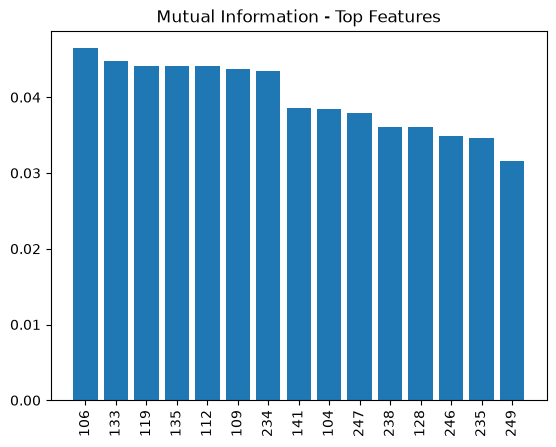

In [79]:
import numpy as np
import matplotlib.pyplot as plt

mi_scores = mutual_info_classif(X_train_processed, y_train)

idx = np.argsort(mi_scores)[::-1]
top_n = 15

plt.figure()
plt.bar(range(top_n), mi_scores[idx][:top_n])
plt.xticks(range(top_n), idx[:top_n], rotation=90)
plt.title("Mutual Information - Top Features")
plt.show()

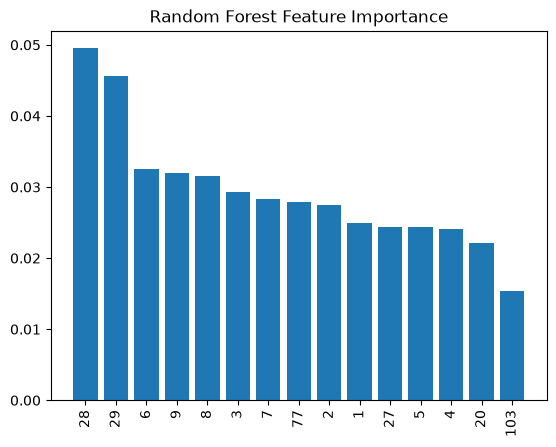

In [80]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_processed,y_train)
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]

plt.figure()
plt.bar(range(15), importances[idx][:15])
plt.xticks(range(15), idx[:15], rotation=90)
plt.title("Random Forest Feature Importance")
plt.show()

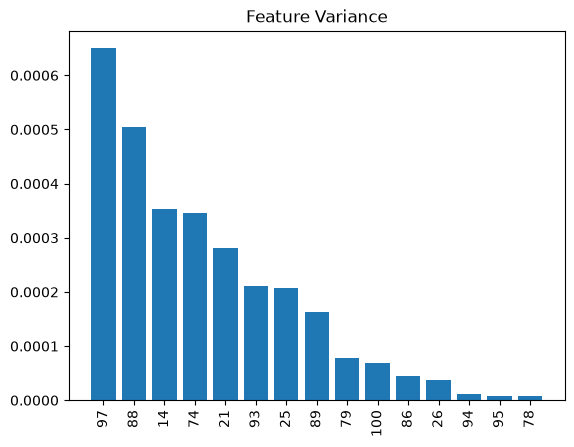

In [54]:
vt = VarianceThreshold(threshold=0.01)
X_filtered = vt.fit_transform(X_train_processed)
variances = vt.variances_
idx = np.argsort(variances)[::-1]

plt.figure()
plt.bar(range(15), variances[idx][-15:])
plt.xticks(range(15), idx[:15], rotation=90)
plt.title("Feature Variance")
plt.show()

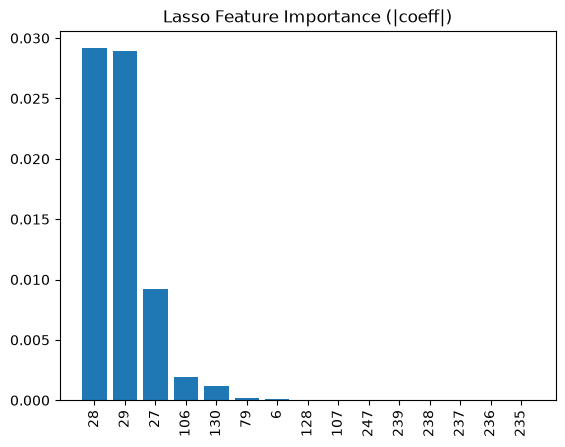

In [81]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X_train_processed)

lasso = Lasso(alpha=0.01)
lasso.fit(X_scaled, y_train)

coef = np.abs(lasso.coef_)
idx = np.argsort(coef)[::-1]

plt.figure()
plt.bar(range(15), coef[idx][:15])
plt.xticks(range(15), idx[:15], rotation=90)
plt.title("Lasso Feature Importance (|coeff|)")
plt.show()

In [82]:
rfe_selector = RFE(LogisticRegression(), n_features_to_select=10,max_iter=1000)
rfe_selector.fit(X_train_processed, y_train)
X_rfe = rfe_selector.transform(X)
rfe_ranking = rfe_selector.ranking_

idx = np.argsort(rfe_ranking)

plt.figure()
plt.bar(range(15), rfe_ranking[idx][:15])
plt.xticks(range(15), idx[:15], rotation=90)
plt.title("RFE Feature Ranking (lower = better)")
plt.gca().invert_yaxis()
plt.show()

TypeError: RFE.__init__() got an unexpected keyword argument 'max_iter'

Selected features: [False  True False  True]
